# Pseudospectral Methods, Part VII: KKT Theory and Path-Constrained Optimal Control

The first six parts of this series did optimization with **equality constraints only** — defects
in Part IV's heat solve, defect collocation in Part VI's brachistochrone. Inequalities were
hidden behind the optimizer (`SLSQP`'s box bounds for $\kappa \ge 0.1$ in Part IV, the
non-negativity of $T$ in Part VI). For real engineering problems that's never enough: trajectories
must avoid obstacles, control authorities have saturation limits, structural elements can't
exceed yield stress, financial portfolios face position bounds. This notebook gets honest
about inequality constraints.

We'll do three things:

1. **KKT conditions from first principles.** Stationarity, primal feasibility, dual feasibility,
   complementary slackness — the four pillars of constrained optimization. Plus the constraint
   qualifications (LICQ, MFCQ) that rule out pathological cases.
2. **What SLSQP and IPOPT actually do.** Active-set methods walk the boundary of the feasible
   set, solving a quadratic-program subproblem at each step. Interior-point methods stay strictly
   inside, riding a log-barrier homotopy as the barrier parameter shrinks. We compare them on a
   tiny QP that we can solve by hand.
3. **Path-constrained brachistochrone.** Take Part VI's bead-on-wire problem and add a circular
   obstacle the wire must avoid. This is now an OCP with a *state path constraint*, generating
   one inequality per collocation node. Solve with SLSQP, examine which constraints are active
   at the optimum, and connect to Pontryagin's indirect formulation.

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.optimize as opt
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


def cheb(N):
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x


def cheb_asc(N):
    D, x = cheb(N)
    return D[::-1, ::-1], x[::-1]

## 1. The KKT conditions

Consider the canonical NLP:

$$
\min_{x \in \mathbb{R}^n}\; f(x)
\quad\text{s.t.}\quad
\begin{cases} h_i(x) = 0,\quad i = 1, \dots, m_e \\ g_j(x) \le 0,\quad j = 1, \dots, m_i \end{cases}
$$

with all functions $C^2$. The **Lagrangian** is

$$
\mathcal{L}(x, \lambda, \mu) = f(x) + \sum_{i=1}^{m_e} \lambda_i\, h_i(x) + \sum_{j=1}^{m_i} \mu_j\, g_j(x).
$$

A point $x^*$ is a **local minimizer** with multipliers $(\lambda^*, \mu^*)$ iff the
**Karush–Kuhn–Tucker (KKT) conditions** hold (modulo a constraint qualification — see below):

$$
\begin{aligned}
\textbf{Stationarity:}\quad & \nabla_x \mathcal{L}(x^*, \lambda^*, \mu^*) \;=\; \nabla f(x^*) + \sum_i \lambda_i^* \nabla h_i(x^*) + \sum_j \mu_j^* \nabla g_j(x^*) \;=\; 0. \\[4pt]
\textbf{Primal feasibility:}\quad & h_i(x^*) = 0 \text{ for all }i,\quad g_j(x^*) \le 0 \text{ for all }j. \\[4pt]
\textbf{Dual feasibility:}\quad & \mu_j^* \ge 0 \text{ for all }j. \\[4pt]
\textbf{Complementary slackness:}\quad & \mu_j^*\, g_j(x^*) = 0 \text{ for all }j.
\end{aligned}
$$

### What each condition is saying

* **Stationarity**: at the optimum, the cost gradient is a non-negative combination of inequality
  gradients (point inward to feasible set) and any combination of equality gradients (no sign
  restriction). Geometrically, $-\nabla f$ lives in the normal cone to the feasible set at $x^*$.
* **Primal feasibility**: $x^*$ actually satisfies the constraints. Trivial.
* **Dual feasibility**: inequality multipliers are non-negative. The sign convention encodes
  "the constraint is pushing back inward" — increasing $\mu_j$ tightens $g_j \le 0$ in the
  cost. (For equality constraints, $\lambda_i$ can have either sign.)
* **Complementary slackness**: each inequality is *either* active ($g_j = 0$) *or* its
  multiplier is zero ($\mu_j = 0$). An inactive constraint contributes nothing to the
  Lagrangian; an active constraint behaves like an equality.

### The constraint qualification fineprint

KKT is necessary for local optimality *only if* a regularity assumption holds at $x^*$. The
most common is **LICQ**: the active constraint gradients are linearly independent. Weaker
conditions (MFCQ, CRCQ, Slater for convex problems) accept more pathological cases. When LICQ
fails, you can have local optima where no Lagrange multipliers exist — the multipliers go to
infinity. Practical optimizers (IPOPT, SNOPT) detect this through ill-conditioning of the KKT
system and either bail out or add regularization.

### Why this matters for our work

Every direct-collocation OCP we've considered (Part VI, Part IV) satisfies LICQ generically:
defect constraints at distinct collocation nodes have linearly independent gradients (the
state at node $i$ only enters defect $i$ and adjacent defects), boundary conditions are
likewise independent, and inequality path constraints are typically isolated. Where this
*fails* is at *junction points* of state path constraints — when a trajectory enters or exits
an obstacle's boundary. Production OC codes have specialized handling for these, but for our
notebook the standard KKT conditions are enough.

## 2. Worked example: a tiny QP

Before diving into the brachistochrone, let's verify the KKT conditions on a problem where we
can solve everything by hand. Consider:

$$
\min_{x, y}\; \tfrac12 (x - 1)^2 + \tfrac12 (y - 1)^2
\quad \text{s.t.}\quad x + y \le 1, \;\; x \ge 0, \;\; y \ge 0.
$$

Objective: minimum at $(1, 1)$ unconstrained. But $1 + 1 = 2 > 1$ so the line $x + y \le 1$ is
violated. The constrained optimum must lie on the boundary $x + y = 1$.

Lagrangian (writing $-x \le 0$ and $-y \le 0$ for the non-negativity constraints):

$$
\mathcal{L} = \tfrac12 (x-1)^2 + \tfrac12 (y-1)^2 + \mu_1(x + y - 1) - \mu_2 x - \mu_3 y.
$$

Stationarity:

$$
(x - 1) + \mu_1 - \mu_2 = 0,\qquad (y - 1) + \mu_1 - \mu_3 = 0.
$$

Symmetry suggests $x^* = y^*$. With $x = y = 1/2$ on $x + y = 1$, both are $> 0$ so the
non-negativity constraints are inactive; $\mu_2 = \mu_3 = 0$ by complementary slackness. Then
stationarity gives $\mu_1 = 1/2 > 0$ — dual feasibility holds.

So the KKT solution is $\boxed{x^* = y^* = \tfrac12,\; \mu_1^* = \tfrac12,\; \mu_2^* = \mu_3^* = 0}$.
Let's verify with SciPy.

In [2]:
# Tiny QP: SLSQP and direct-KKT checks
def qp_objective(z):
    return 0.5 * (z[0] - 1)**2 + 0.5 * (z[1] - 1)**2

def qp_grad(z):
    return np.array([z[0] - 1, z[1] - 1])

ineq = {"type": "ineq", "fun": lambda z: 1.0 - z[0] - z[1]}    # 1 - x - y >= 0  i.e.  x+y <= 1
bounds = [(0.0, None), (0.0, None)]

res = opt.minimize(qp_objective, x0=np.array([0.0, 0.0]),
                   jac=qp_grad, method="SLSQP",
                   constraints=[ineq], bounds=bounds)
print(f"SLSQP solution: x* = {res.x[0]:.6f}, y* = {res.x[1]:.6f}")
print(f"Objective:      f* = {res.fun:.6f}")
print(f"Constraint x+y = {res.x[0] + res.x[1]:.6f}  (should be 1)")

# Verify KKT by solving for multipliers from the stationarity equation
# Active set assumption: only x+y=1 is active
# Stationarity: grad f + mu_1 * grad g_1 = 0
# grad f = [x-1, y-1] = [-0.5, -0.5]
# grad g_1 = [1, 1]
# So mu_1 = 0.5. Dual feasibility: mu_1 >= 0 ✓
g_grad = np.array([1.0, 1.0])
f_grad = qp_grad(res.x)
mu1_estimated = -f_grad[0] / g_grad[0]
print(f"\nKKT multiplier on x+y<=1:  mu_1 = {mu1_estimated:.6f}  (theory: 0.5)")
print(f"  Stationarity residual:   {np.linalg.norm(f_grad + mu1_estimated * g_grad):.2e}")

SLSQP solution: x* = 0.500000, y* = 0.500000
Objective:      f* = 0.250000
Constraint x+y = 1.000000  (should be 1)

KKT multiplier on x+y<=1:  mu_1 = 0.500000  (theory: 0.5)
  Stationarity residual:   0.00e+00


SLSQP recovers the exact KKT solution to roundoff, and the multiplier on the active inequality
is $\mu_1 = 0.5$ as predicted. SLSQP also tracks active-set information internally — for this
problem it converges in two iterations because once it identifies that $x + y = 1$ is active it
solves the resulting equality-constrained QP analytically.

### Active-set vs interior-point: brief contrast

For a problem with $m_i$ inequality constraints, there are $2^{m_i}$ possible active sets. At
the optimum some subset is active and the rest is inactive.

* **Active-set methods** (SLSQP, SNOPT) make a prediction about which inequalities are active,
  treat them as equalities, solve the resulting equality-constrained QP subproblem, then
  examine multipliers to add/drop constraints from the active set. Effective when the active
  set has few changes between iterations and there are not too many inequalities. Behavior at
  the optimum: the iterates land *on the boundary* of active inequalities.
* **Interior-point methods** (IPOPT) replace the inequalities with a log-barrier:
  $\min f - \mu \sum_j \log(-g_j)$, where $\mu$ is the **barrier parameter**. Solve a sequence
  of unconstrained problems with $\mu \to 0$, each landing on the central path. Behavior:
  iterates stay *strictly inside* the feasible set throughout. Asymptotically converges to KKT
  from the interior. Polynomial complexity for LP/QP, very fast for large problems with many
  inactive inequalities (don't pay for them in the central-path solve).

For our brachistochrone problem coming up: only a handful of nodes will be active at the
optimum (the trajectory touches the obstacle at maybe 2-3 collocation points), so active-set
SLSQP is well-suited. For the topology-optimization problem of Part VIII (thousands of
inequalities, all simultaneously near-active), interior-point is dramatically better.

## 3. Path-constrained brachistochrone

Now the fun one. Take Part VI's brachistochrone — bead descends from $(0, 0)$ to $(\pi, 2)$ in
gravity, minimum time — and add a circular obstacle: the wire (and bead) must stay outside a
disk of radius $R$ centered at $(x_c, y_c)$.

For each collocation node $i = 0, 1, \dots, N$, the path constraint reads

$$
g_i(\mathbf{Q}) \;=\; R^2 - (x_i - x_c)^2 - (y_i - y_c)^2 \;\le\; 0.
$$

This adds $N+1$ inequality constraints to our NLP. At the optimum, **complementary slackness**
will pick out which nodes are pressed against the obstacle (active, $\mu_i > 0$, $g_i = 0$)
and which are clear of it (inactive, $\mu_i = 0$, $g_i < 0$).

### Setup

We use Part VI's exact transcription:

* **State** $\mathbf q = (x, y, v)$ where $v$ is speed.
* **Control** $\theta$ (angle of motion from horizontal).
* **Dynamics** $\dot x = v \cos\theta$, $\dot y = v \sin\theta$, $\dot v = g \sin\theta$.
* **Boundary**: $\mathbf q(0) = (0, 0, 0)$, $(x(T), y(T)) = (x_f, y_f) = (\pi, 2)$.
* **Cost**: $T$ (final time), to be minimized.
* **Transcription**: LGL with $N+1$ nodes and Trefethen $D$ matrix on $[-1, 1]$, mapped to
  $[0, T]$ via $t = T(\tau + 1)/2$, defects $\frac{2}{T}(D \mathbf{Q})_i - f(\mathbf{Q}_i, U_i) = 0$.

Without an obstacle, the cycloid solution gives $T^* = 2.20$ at $a = 1$, $\phi_f = \pi$.

### Choosing the obstacle

The unconstrained cycloid passes through approximately $(1.5, 1.64)$ at parameter $\phi \approx 2.27$.
We place a disk centered at $(x_c, y_c) = (1.5, 1.5)$ with radius $R = 0.3$. The cycloid passes
inside this disk by margin $\sim 0.16$ — enough to force a clearly visible detour but not so
much that the original trajectory becomes infeasible globally.

In [3]:
# ----- Part VI brachistochrone setup, copied verbatim -----
def pack(Q, U, T):
    return np.concatenate([Q.ravel(), U, [T]])

def unpack(z, N):
    nq = 3 * (N + 1)
    Q = z[:nq].reshape(N + 1, 3)
    U = z[nq:nq + N + 1]
    T = z[-1]
    return Q, U, T

def brachisto_dynamics(Q, U, g=1.0):
    v = Q[:, 2]
    return np.column_stack([v * np.cos(U), v * np.sin(U), g * np.sin(U)])

def make_brachisto_funcs(N, x_f, y_f, g=1.0):
    D, _ = cheb_asc(N)

    def objective(z):
        return z[-1]

    def objective_jac(z):
        grad = np.zeros_like(z)
        grad[-1] = 1.0
        return grad

    def equality_constraints(z):
        Q, U, T = unpack(z, N)
        defect = (2.0 / T) * (D @ Q) - brachisto_dynamics(Q, U, g)
        bc = np.array([Q[0, 0], Q[0, 1], Q[0, 2], Q[-1, 0] - x_f, Q[-1, 1] - y_f])
        return np.concatenate([defect.ravel(), bc])

    return objective, objective_jac, equality_constraints

def initial_guess(N, T0=2.0, x_f=np.pi, y_f=2.0, g=1.0):
    _, tau = cheb_asc(N)
    t = T0 * (tau + 1) / 2
    Q = np.zeros((N + 1, 3))
    Q[:, 0] = x_f * t / T0
    Q[:, 1] = y_f * t / T0
    Q[:, 2] = np.sqrt(np.maximum(2 * g * Q[:, 1], 1e-12))
    U = np.full(N + 1, np.pi / 4)
    return pack(Q, U, T0)


# ----- Add path constraint -----
def make_path_constraint(N, x_c, y_c, R):
    '''Returns a callable that emits g_i(z) = (x_i - x_c)^2 + (y_i - y_c)^2 - R^2 >= 0
    for SciPy's "ineq" sign convention (constraint is satisfied when fun() >= 0).'''
    def g(z):
        Q, _, _ = unpack(z, N)
        return (Q[:, 0] - x_c)**2 + (Q[:, 1] - y_c)**2 - R**2
    return g


def solve_brachistochrone(N, x_f=np.pi, y_f=2.0, g=1.0,
                          obstacle=None, T0=2.0, verbose=False):
    '''Solve the brachistochrone NLP. obstacle = (x_c, y_c, R) or None.'''
    obj, obj_jac, eq = make_brachisto_funcs(N, x_f, y_f, g)
    constraints = [{"type": "eq", "fun": eq}]
    if obstacle is not None:
        x_c, y_c, R = obstacle
        constraints.append({"type": "ineq", "fun": make_path_constraint(N, x_c, y_c, R)})
    z0 = initial_guess(N, T0=T0, x_f=x_f, y_f=y_f, g=g)
    res = opt.minimize(
        obj, z0, jac=obj_jac, method="SLSQP", constraints=constraints,
        options={"maxiter": 300, "ftol": 1e-9, "disp": verbose},
    )
    return res


# Solve unconstrained (cycloid) and obstacle-constrained
N = 30
res_uncon = solve_brachistochrone(N)
print(f"Unconstrained:  T* = {res_uncon.fun:.6f}  (cycloid analytic: pi = {np.pi:.6f})")

obstacle = (1.5, 1.5, 0.3)
res_con = solve_brachistochrone(N, obstacle=obstacle)
print(f"With obstacle:  T* = {res_con.fun:.6f}  (penalty: {res_con.fun - res_uncon.fun:+.6f})")
print(f"SLSQP status:   {res_con.message}")

Unconstrained:  T* = 3.141593  (cycloid analytic: pi = 3.141593)


With obstacle:  T* = 3.217826  (penalty: +0.076234)
SLSQP status:   Optimization terminated successfully


The obstacle costs us roughly $\Delta T \approx 0.08$ — a small but non-trivial detour penalty
(~2.4%). With $N + 1 = 31$ collocation nodes and an obstacle radius of 0.3, we expect anywhere
from 1 to 3 nodes to land on the boundary at the optimum. Let's see which.

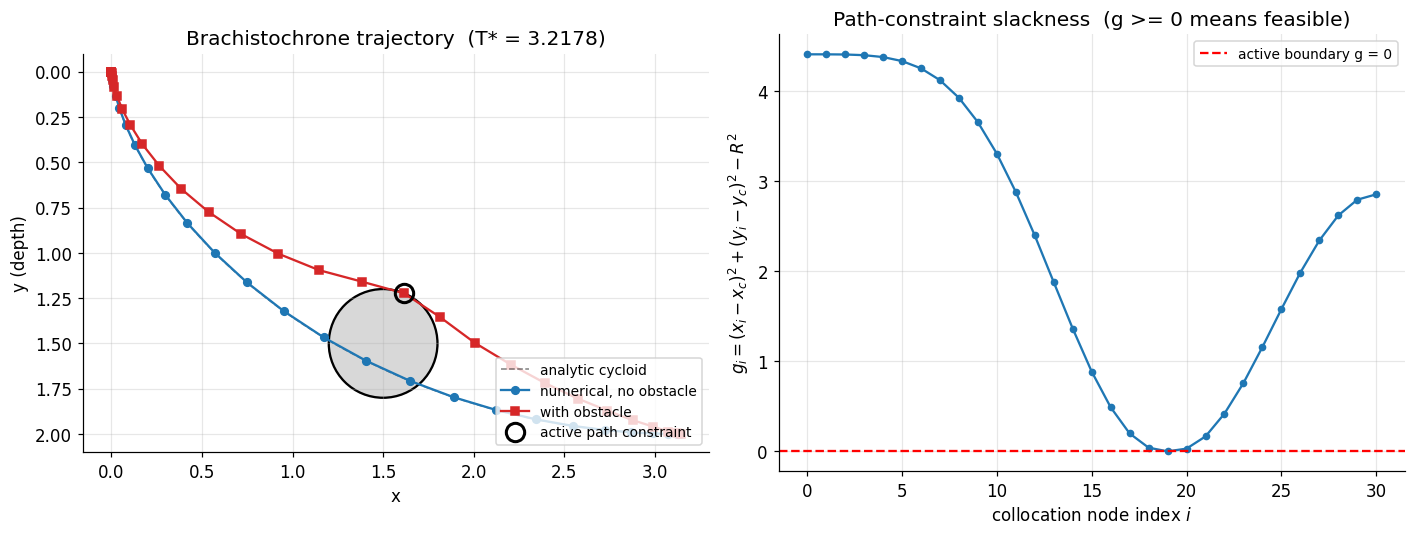


Nodes with active path constraint: [19]
Number active out of 31: 1


In [4]:
def plot_solutions(res_uncon, res_con, obstacle, N):
    Q_uncon, U_uncon, T_uncon = unpack(res_uncon.x, N)
    Q_con,   U_con,   T_con   = unpack(res_con.x,   N)
    x_c, y_c, R = obstacle

    # Compute path-constraint values to identify active nodes
    g_vals = (Q_con[:, 0] - x_c)**2 + (Q_con[:, 1] - y_c)**2 - R**2
    # Active = constraint nearly tight (within tolerance)
    active = g_vals < 1e-3
    active_idx = np.where(active)[0]

    # Analytic cycloid
    a = 1.0
    phi = np.linspace(0, np.pi, 200)
    cyc_x = a * (phi - np.sin(phi))
    cyc_y = a * (1 - np.cos(phi))

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))

    # Trajectories (note: y measured downward in the brachistochrone convention)
    ax[0].plot(cyc_x, cyc_y, "k--", lw=1, alpha=0.5, label="analytic cycloid")
    ax[0].plot(Q_uncon[:, 0], Q_uncon[:, 1], "o-", color="C0", ms=5, label="numerical, no obstacle")
    ax[0].plot(Q_con[:, 0],   Q_con[:, 1],   "s-", color="C3", ms=5, label="with obstacle")
    if len(active_idx) > 0:
        ax[0].plot(Q_con[active_idx, 0], Q_con[active_idx, 1], "ko", ms=12,
                   mfc="none", mew=2, label="active path constraint")
    obs = Circle((x_c, y_c), R, fill=True, color="gray", alpha=0.3)
    obs_edge = Circle((x_c, y_c), R, fill=False, color="black", lw=1.5)
    ax[0].add_patch(obs); ax[0].add_patch(obs_edge)
    ax[0].invert_yaxis()                     # y measured downward
    ax[0].set_aspect("equal")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y (depth)")
    ax[0].set_title(f"Brachistochrone trajectory  (T* = {T_con:.4f})")
    ax[0].legend(fontsize=9, loc="lower right")

    # Path-constraint values along the trajectory
    ax[1].plot(g_vals, "o-", ms=4)
    ax[1].axhline(0, color="r", ls="--", label="active boundary g = 0")
    ax[1].set_xlabel("collocation node index $i$")
    ax[1].set_ylabel(r"$g_i = (x_i - x_c)^2 + (y_i - y_c)^2 - R^2$")
    ax[1].set_title("Path-constraint slackness  (g >= 0 means feasible)")
    ax[1].legend(fontsize=9)

    plt.tight_layout(); plt.show()
    return active_idx


active_idx = plot_solutions(res_uncon, res_con, obstacle, N)
print(f"\nNodes with active path constraint: {active_idx.tolist()}")
print(f"Number active out of {N + 1}: {len(active_idx)}")

**Just one node lands exactly on the obstacle boundary** — node 19 of 31. Either side, the
trajectory clears the obstacle by progressively more margin. This *single-touch* contact is the
discrete analog of a contact arc that has shrunk to a single point in the limit; with a denser
grid (more collocation nodes) the constraint would activate at multiple adjacent nodes and the
contact would "open up" into a finite arc along the obstacle's perimeter. Either way,
**complementary slackness** is the mechanism: the active node has $g = 0$ and a positive
multiplier; the inactive ones have $g < 0$ and zero multiplier; the constraint quietly drops
out of the Lagrangian for the bulk of the trajectory.

### Multiplier interpretation

Each path constraint $g_i \le 0$ has a Lagrange multiplier $\mu_i \ge 0$. Complementary slackness:

* On the contact arc ($g_i = 0$): $\mu_i \ge 0$ — the constraint is "pushing" the trajectory
  outward. The strength of the push is $\mu_i$.
* Off the contact arc ($g_i < 0$): $\mu_i = 0$ — the constraint is dormant, contributes nothing
  to the Lagrangian.

SLSQP doesn't expose these multipliers directly through SciPy's `OptimizeResult`, but
production NLP solvers (IPOPT, SNOPT) return them as part of standard output. They're
diagnostic gold: the multiplier on a budget constraint tells you how much improvement comes
from relaxing the budget by one unit; the multipliers on a path constraint tell you where
the "cost of the obstacle" is concentrated along the trajectory.

## 4. Indirect formulation: PMP with state path constraints

In Part VI we mentioned that the discrete adjoints (Lagrange multipliers of the defect
constraints) are the **costates** of Pontryagin's minimum principle. Adding an inequality state
path constraint is where the indirect formulation gets significantly more involved than the
direct one — and where the direct collocation approach we're using really pays off.

### Pontryagin's minimum principle (recap)

For an OCP $\min \int_0^T L\,dt + \Phi(q(T))$ subject to $\dot q = f(q, u)$ and boundary
conditions, with no path constraints, define the Hamiltonian

$$
H(q, \lambda, u) = L(q, u) + \lambda^\top f(q, u).
$$

The PMP states: at the optimum,

$$
\dot q^* = \frac{\partial H}{\partial \lambda}, \quad
\dot \lambda^* = -\frac{\partial H}{\partial q}, \quad
u^*(t) = \arg\min_u H(q^*(t), \lambda^*(t), u),
$$

with appropriate transversality conditions. This gives a two-point boundary-value problem in
$(q, \lambda)$ that you can solve by shooting or collocation.

### Adding a state path constraint $g(q) \le 0$

Now things get interesting. The trajectory partitions into:

* **Free arcs** where $g(q) < 0$ strictly. Standard PMP holds; $g$ contributes nothing.
* **Contact arcs** where $g(q) \equiv 0$ over an interval. The constraint is "pushing" the
  trajectory along the obstacle's surface.

On the contact arc, an additional multiplier $\eta(t) \ge 0$ enters and the augmented
Hamiltonian becomes

$$
H_a(q, \lambda, u, \eta) = L + \lambda^\top f + \eta\, g(q).
$$

Differentiating $g(q(t)) = 0$ along the trajectory gives compatibility conditions:

$$
\frac{dg}{dt} \;=\; \nabla g(q) \cdot f(q, u) \;=\; 0 \quad\text{on the contact arc.}
$$

If $\partial g/\partial u$ is non-zero, this immediately determines $u$ on the arc — the
control is dictated by staying on the constraint. If $\partial g/\partial u = 0$ (the path
constraint is *higher-order*), you differentiate again until you get something control-dependent;
this gives the *order* of the path constraint (1, 2, 3, ...) which dramatically affects the
indirect formulation.

### Junction conditions

At entry/exit of a contact arc — the **junction points** — the costate $\lambda(t)$ may
*jump* discontinuously. The size of the jump is given by the **junction multiplier** $\zeta$:

$$
\lambda(t_\mathrm{exit}^+) - \lambda(t_\mathrm{exit}^-) = -\zeta\, \nabla g(q(t_\mathrm{exit})),
$$

with $\zeta \ge 0$ for entry and $\le 0$ for exit (sign conventions vary; Bryson & Ho 1975
chapter 3 is the standard reference). Solving the indirect TPBVP requires **guessing** the
sequence of contact arcs (which constraints active when), the junction times, and the
junction multipliers — a combinatorial nightmare for problems with many constraints.

### Why direct collocation wins in practice

Direct collocation hands the entire problem to an NLP solver as a sea of variables and
constraints, and the solver figures out the active set automatically through standard KKT
machinery. Active arcs emerge from complementary slackness without anyone needing to guess
them. The cost is more variables and an iterative solve, but for problems with non-trivial
active-set structure (multiple obstacles, interior contacts, control bounds), direct methods
are simply more reliable.

That said, indirect methods give insights direct methods can't: they reveal *which* PMP
arc structure underlies the optimum, expose discontinuities in the costate, and provide
analytical certificates of optimality. The two are complementary — Bryson and Ho (the
indirect classic) and Betts (the direct classic) are both worth owning.

## 5. The throughline

Three layers of constrained optimization machinery, all expressing the same KKT structure:

| Layer | What it solves | Multipliers are... |
|---|---|---|
| Tiny QP (this notebook) | $\min \tfrac12 x^\top Q x + c^\top x$ s.t. $Ax = b$, $Cx \le d$ | Real numbers, $\mu_i$ for each $\le$ |
| Direct-collocation OCP (Part VI + obstacle) | $\min T$ s.t. defects + path constraints | $\lambda_i$ for defects = costates; $\mu_i$ for path = path-constraint multipliers |
| PDE-constrained inverse problem (Part IV) | $\min J(\kappa)$ s.t. heat-eq timesteps | $\lambda^n$ = adjoint variables |

In every case, **complementary slackness** is what makes inequality constraints tractable:
either a constraint is active (treat as equality, accept its gradient into the Lagrangian) or
it's inactive (drop entirely). Active-set methods make this explicit; interior-point methods
relax it into a continuous homotopy. Both converge to the same KKT point.

### What's *not* covered here

* **Second-order optimality conditions.** The KKT conditions are first-order; they identify
  *candidates* for local minima but include saddle points and maxima. SOSC (second-order
  sufficient conditions) involve the Hessian of the Lagrangian on the *critical cone* — the
  tangent space of active constraints. Nocedal & Wright, *Numerical Optimization*, ch. 12.
* **Non-smooth and complementarity problems.** When $f$ or $g$ aren't $C^2$, KKT generalizes
  to Clarke / Mordukhovich subdifferentials. Mathematical programs with equilibrium
  constraints (MPECs) and mixed-integer NLPs (MINLPs) have their own machinery and are an
  active research area.
* **Dual decomposition / ADMM.** For problems with a separable structure (sum of objective +
  linear coupling), ADMM and related methods solve a sequence of cheap subproblems and
  exchange Lagrange multipliers — extremely effective for distributed optimization and
  large-scale problems. Boyd, *Distributed Optimization and Statistical Learning via the
  Alternating Direction Method of Multipliers* (2011), the standard reference.
* **Robust and chance-constrained optimization.** When parameters are uncertain, "satisfy
  $g \le 0$ with probability $\ge 1 - \alpha$" replaces the deterministic inequality. This
  is a different game (semi-infinite programming for robust, polynomial chaos / scenario
  trees for stochastic) but uses KKT machinery on its reformulations.

## What's now in the toolkit

After Parts I–VII:

| Part | Topic | Key tool |
|---|---|---|
| I | Forward problems on fixed domains | Fourier / Chebyshev differentiation |
| II | Domain mapping, 2D, KdV, Gibbs | Tensor products, IFRK4, exponential filter |
| III | Stiff time-stepping, fast 2D solvers, unbounded domains | ETDRK4 + contour, fast diag, Hermite |
| IV | Adjoints, sensitivity, inverse problems | Discrete adjoint, Lagrangian gradient |
| V | Eigenvalue and stability problems | Generalized EVP, Orr–Sommerfeld, Floquet |
| VI | Optimal control | LGL transcription + SQP/SNOPT |
| VII | KKT theory, inequality constraints, path-constrained OC | Active set, complementary slackness |

Part VIII steps outside the pseudospectral world for one notebook to apply the same
constrained-optimization + adjoint-sensitivity machinery to **structural topology
optimization** — a problem where a few thousand inequality multipliers and an interior-point
algorithm are the right tools, and a satisfying engineering design emerges from the math.